In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost statsmodels tensorflow keras -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import zscore
from statsmodels.tsa.arima.model import ARIMA
import xgboost as xgb

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries imported successfully")

All libraries imported successfully


In [3]:
!wget -q "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"
!unzip -q household_power_consumption.zip
print("Dataset downloaded and extracted")

Dataset downloaded and extracted


##**Load Raw Data**

In [4]:
df = pd.read_csv(
    'household_power_consumption.txt',
    sep=';',
    low_memory=False,
    na_values=['?']
)

print("Shape:", df.shape)
print("\nFirst 3 rows:")
df.head(3)

Shape: (2075259, 9)

First 3 rows:


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0


##**Data Preprocessing**

In [5]:
# Step 1 — Combine Date and Time into datetime
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')

# Step 2 — Set datetime as index
df.set_index('datetime', inplace=True)

# Step 3 — Drop original Date and Time columns
df.drop(columns=['Date', 'Time'], inplace=True)

# Step 4 — Convert all columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 5 — Check missing values before filling
print("Missing values before fill:")
print(df.isnull().sum())

# Step 6 — Forward fill missing values
df.ffill(inplace=True)

# Step 7 — Resample from minute to hourly
hourly = df.resample('h').mean()

print("\nShape after resampling:", hourly.shape)
print("\nMissing values after:")
print(hourly.isnull().sum())
print("\nSample:")
hourly.head(3)

Missing values before fill:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Shape after resampling: (34589, 7)

Missing values after:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

Sample:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333


##**Save Cleaned Dataset**

In [6]:
hourly.to_csv('final_electricity_dataset.csv')
print("Cleaned dataset saved")
print("Total records:", len(hourly))
print("Date range:", hourly.index.min(), "to", hourly.index.max())
hourly.describe()

Cleaned dataset saved
Total records: 34589
Date range: 2006-12-16 17:00:00 to 2010-11-26 21:00:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000,34589.000000
mean,1.086200,0.123326,240.841505,4.604360,1.110951,1.287914,6.416515
std,0.894942,0.067221,2.999127,3.746337,3.518498,4.168720,7.344718
min,0.124000,0.000000,225.834500,0.503333,0.000000,0.000000,0.000000
25%,0.341267,0.077667,239.197167,1.510000,0.000000,0.000000,0.650000
50%,0.799533,0.106767,240.984500,3.406667,0.000000,0.333333,1.650000
75%,1.574967,0.149367,242.691833,6.583333,0.000000,0.650000,14.083333
max,6.560533,0.774333,251.902000,28.383333,48.366667,46.433333,21.550000


##**EDA: Overall Trend**

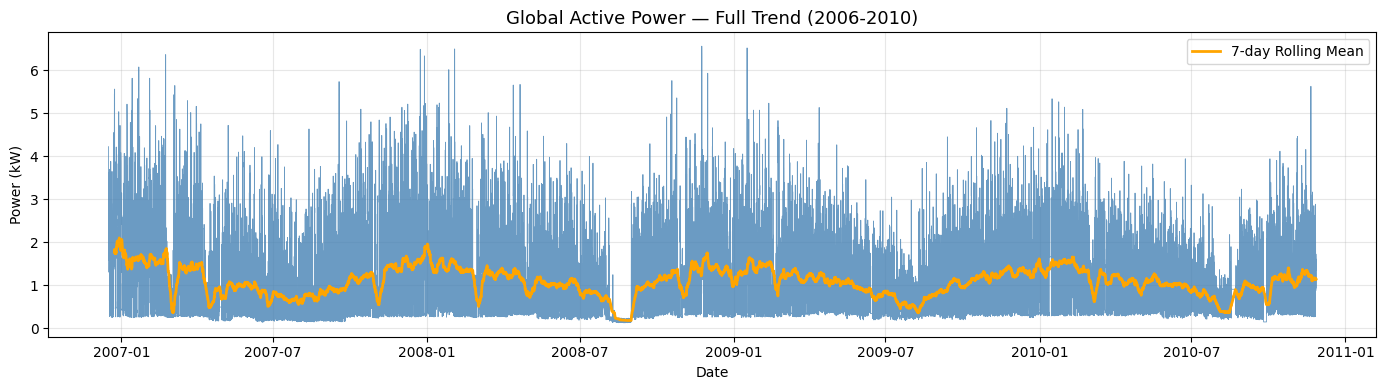

In [7]:
plt.figure(figsize=(14, 4))
plt.plot(hourly.index, hourly['Global_active_power'],
         color='steelblue', linewidth=0.6, alpha=0.8)
plt.plot(hourly.index,
         hourly['Global_active_power'].rolling(24*7).mean(),
         color='orange', linewidth=2, label='7-day Rolling Mean')
plt.title('Global Active Power — Full Trend (2006-2010)', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('eda_trend.png', dpi=150)
plt.show()

##**EDA: Monthly Average**

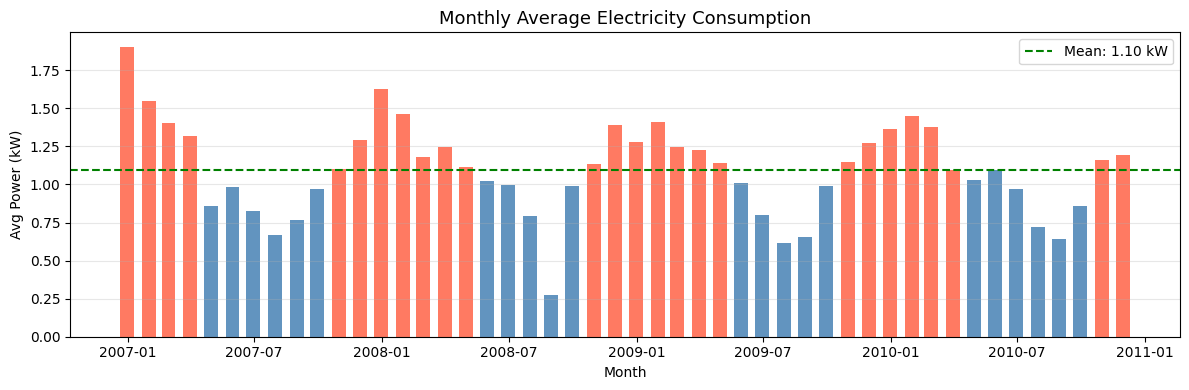

Peak month: December 2006 — 1.904 kW
Lowest month: August 2008 — 0.277 kW


In [8]:
monthly = hourly['Global_active_power'].resample('ME').mean()

plt.figure(figsize=(12, 4))
colors = ['tomato' if v >= monthly.mean() else 'steelblue' for v in monthly.values]
plt.bar(monthly.index, monthly.values, width=20, color=colors, alpha=0.85)
plt.axhline(monthly.mean(), color='green', linestyle='--', linewidth=1.5,
            label=f'Mean: {monthly.mean():.2f} kW')
plt.title('Monthly Average Electricity Consumption', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Avg Power (kW)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('eda_monthly.png', dpi=150)
plt.show()

print(f"Peak month: {monthly.idxmax().strftime('%B %Y')} — {monthly.max():.3f} kW")
print(f"Lowest month: {monthly.idxmin().strftime('%B %Y')} — {monthly.min():.3f} kW")

##**EDA: Hourly Pattern**

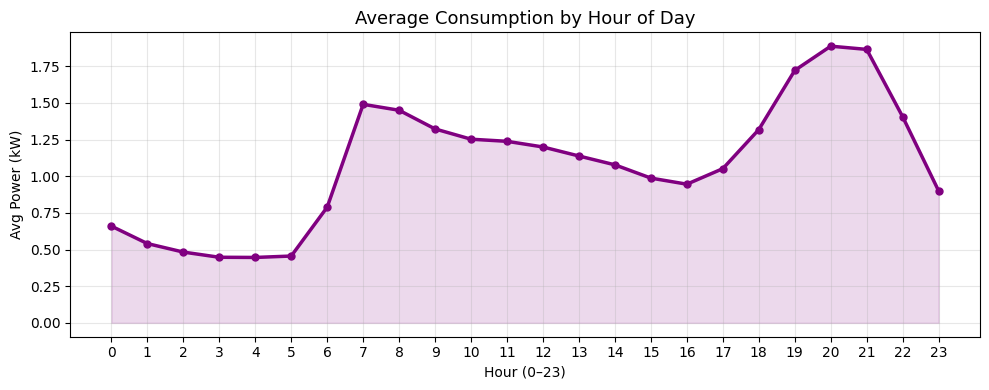

Peak hour: 20:00 — 1.887 kW
Lowest hour: 4:00 — 0.446 kW


In [9]:
hourly_avg = hourly.groupby(hourly.index.hour)['Global_active_power'].mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly_avg.index, hourly_avg.values,
         color='purple', linewidth=2.5, marker='o', markersize=5)
plt.fill_between(hourly_avg.index, hourly_avg.values, alpha=0.15, color='purple')
plt.title('Average Consumption by Hour of Day', fontsize=13)
plt.xlabel('Hour (0–23)')
plt.ylabel('Avg Power (kW)')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('eda_hourly.png', dpi=150)
plt.show()

print(f"Peak hour: {hourly_avg.idxmax()}:00 — {hourly_avg.max():.3f} kW")
print(f"Lowest hour: {hourly_avg.idxmin()}:00 — {hourly_avg.min():.3f} kW")

##**EDA: Weekday Pattern**

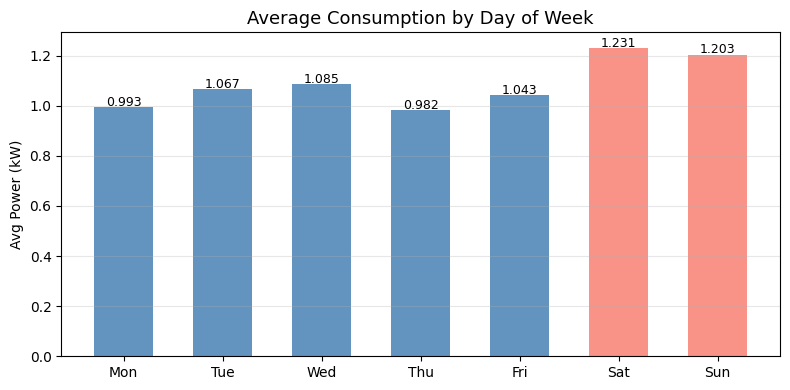

In [10]:
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_avg = hourly.groupby(hourly.index.weekday)['Global_active_power'].mean()

plt.figure(figsize=(8, 4))
colors = ['salmon' if i >= 5 else 'steelblue' for i in range(7)]
bars = plt.bar(days, day_avg.values, color=colors, width=0.6, alpha=0.85)
for bar, val in zip(bars, day_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=9)
plt.title('Average Consumption by Day of Week', fontsize=13)
plt.ylabel('Avg Power (kW)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('eda_weekday.png', dpi=150)
plt.show()

##**EDA: Correlation Heatmap**

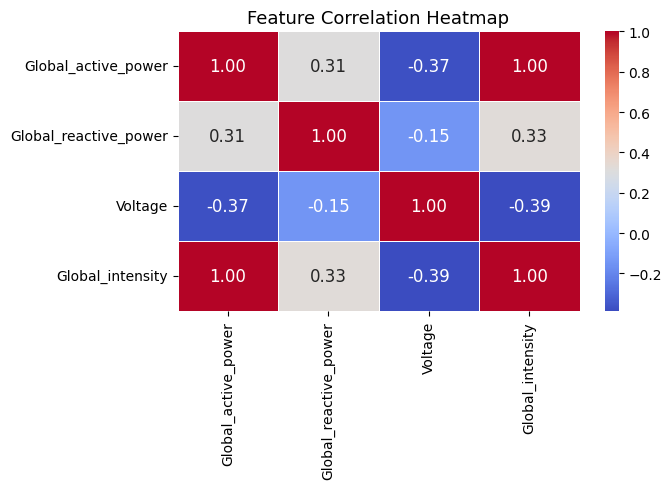

In [11]:
corr_cols = ['Global_active_power', 'Global_reactive_power',
             'Voltage', 'Global_intensity']

plt.figure(figsize=(7, 5))
sns.heatmap(hourly[corr_cols].corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 12})
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig('eda_heatmap.png', dpi=150)
plt.show()

##**EDA: Seasonal Heatmap**

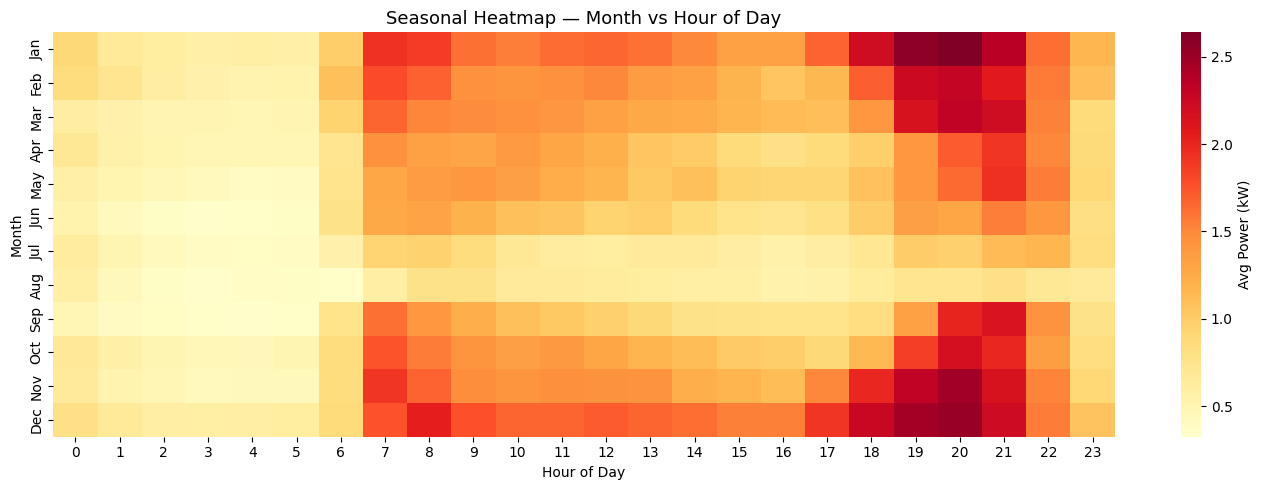

In [12]:
pivot = hourly.groupby([hourly.index.month, hourly.index.hour])['Global_active_power'].mean().unstack()
pivot.index = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0,
            cbar_kws={'label': 'Avg Power (kW)'})
plt.title('Seasonal Heatmap — Month vs Hour of Day', fontsize=13)
plt.xlabel('Hour of Day')
plt.ylabel('Month')
plt.tight_layout()
plt.savefig('eda_seasonal_heatmap.png', dpi=150)
plt.show()

##**Feature Engineering**

In [13]:
data = hourly.copy()

# Time features
data['hour']    = data.index.hour
data['day']     = data.index.day
data['month']   = data.index.month
data['weekday'] = data.index.weekday

# Lag features
data['lag_1']  = data['Global_active_power'].shift(1)
data['lag_24'] = data['Global_active_power'].shift(24)

# Rolling features
data['rolling_mean_24'] = data['Global_active_power'].rolling(24).mean()
data['rolling_std_24']  = data['Global_active_power'].rolling(24).std()

# Drop NaN rows created by lag/rolling
data.dropna(inplace=True)

print("Shape after feature engineering:", data.shape)
print("\nFeature columns:")
print(data.columns.tolist())
data.head(3)

Shape after feature engineering: (34565, 15)

Feature columns:
['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'day', 'month', 'weekday', 'lag_1', 'lag_24', 'rolling_mean_24', 'rolling_std_24']


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day,month,weekday,lag_1,lag_24,rolling_mean_24,rolling_std_24
datetime,,,,,,,,,,,,,,,
2006-12-17 17:00:00,3.406767,0.166633,234.229833,14.510000,0.0,0.466667,16.816667,17,17,12,6,3.326033,4.222889,2.465140,0.752521
2006-12-17 18:00:00,3.697100,0.135067,234.372333,15.750000,0.0,0.000000,16.833333,18,17,12,6,3.406767,3.632200,2.467844,0.757001
2006-12-17 19:00:00,2.908400,0.265167,233.195667,12.516667,0.0,0.516667,16.683333,19,17,12,6,3.697100,3.400233,2.447351,0.737057


##**Train Test Split (Chronological — No Leakage)**

In [14]:
feature_cols = ['hour', 'day', 'month', 'weekday',
                'lag_1', 'lag_24',
                'rolling_mean_24', 'rolling_std_24']

X = data[feature_cols]
y = data['Global_active_power']

# Proper time-based split — 80% train, 20% test
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print("Training size:", len(X_train))
print("Testing size :", len(X_test))
print("Train period:", X_train.index.min(), "to", X_train.index.max())
print("Test period :", X_test.index.min(),  "to", X_test.index.max())

Training size: 27652
Testing size : 6913
Train period: 2006-12-17 17:00:00 to 2010-02-11 20:00:00
Test period : 2010-02-11 21:00:00 to 2010-11-26 21:00:00


##**Metrics Helper Function**

In [15]:
def evaluate(model_name, actual, predicted):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2   = r2_score(actual, predicted)
    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

    print(f"\n{'='*40}")
    print(f"  {model_name}")
    print(f"{'='*40}")
    print(f"  MAE    : {mae:.4f}")
    print(f"  RMSE   : {rmse:.4f}")
    print(f"  MAPE   : {mape:.2f}%")
    print(f"  R2     : {r2:.4f}")

    return {
        'Model': model_name,
        'MAE':   round(mae,  4),
        'RMSE':  round(rmse, 4),
        'MAPE':  round(mape, 2),
        'R2':    round(r2,   4)
    }

results = []  # will store all model metrics here
print("Metrics function ready")

Metrics function ready


##**Model 1: Linear Regression (Baseline)**


  Linear Regression
  MAE    : 0.3634
  RMSE   : 0.5173
  MAPE   : 48.46%
  R2     : 0.4989


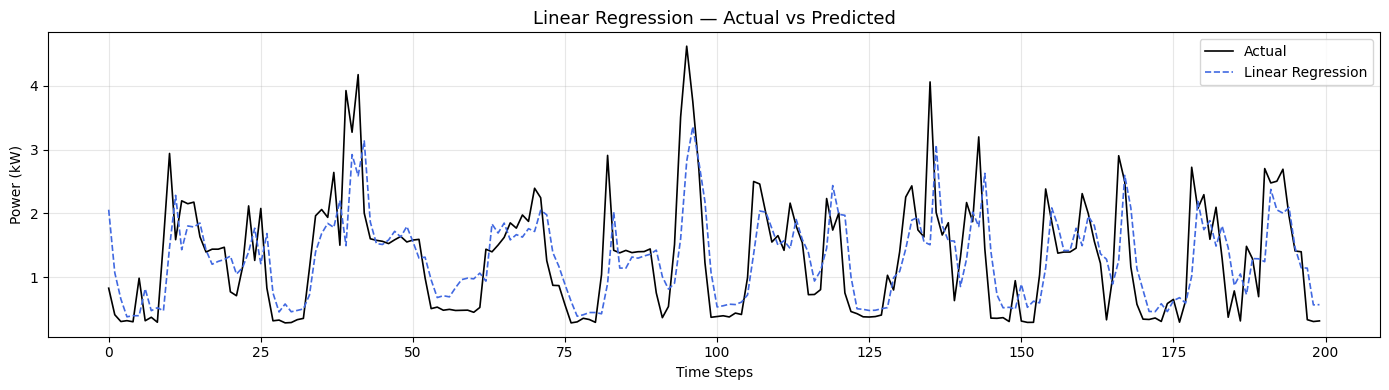

In [16]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_metrics = evaluate("Linear Regression", y_test.values, lr_pred)
results.append(lr_metrics)

# Plot
plt.figure(figsize=(14, 4))
plt.plot(range(200), y_test.values[:200], color='black', linewidth=1.2, label='Actual')
plt.plot(range(200), lr_pred[:200], color='royalblue', linewidth=1.2,
         linestyle='--', label='Linear Regression')
plt.title('Linear Regression — Actual vs Predicted', fontsize=13)
plt.xlabel('Time Steps')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_lr.png', dpi=150)
plt.show()

##**Model 2: Random Forest**


  Random Forest
  MAE    : 0.3282
  RMSE   : 0.4657
  MAPE   : 44.57%
  R2     : 0.5938


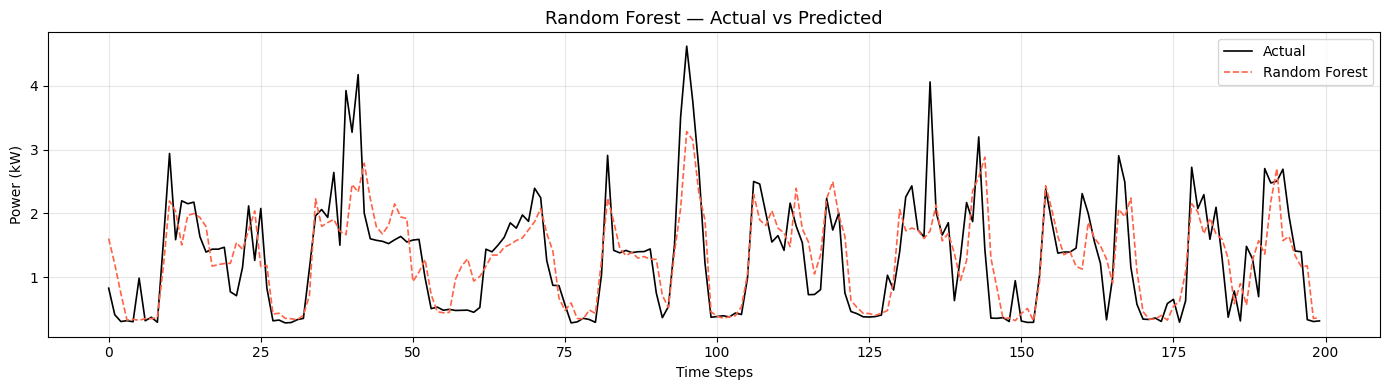

In [17]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_metrics = evaluate("Random Forest", y_test.values, rf_pred)
results.append(rf_metrics)

# Plot
plt.figure(figsize=(14, 4))
plt.plot(range(200), y_test.values[:200], color='black', linewidth=1.2, label='Actual')
plt.plot(range(200), rf_pred[:200], color='tomato', linewidth=1.2,
         linestyle='--', label='Random Forest')
plt.title('Random Forest — Actual vs Predicted', fontsize=13)
plt.xlabel('Time Steps')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_rf.png', dpi=150)
plt.show()

##**Model 3: XGBoost**


  XGBoost
  MAE    : 0.3198
  RMSE   : 0.4573
  MAPE   : 42.09%
  R2     : 0.6084


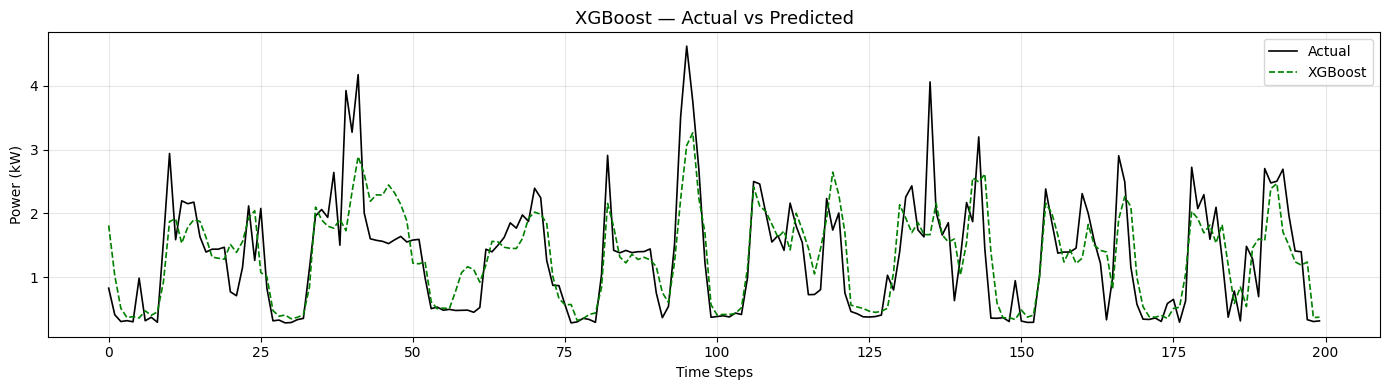

In [18]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_metrics = evaluate("XGBoost", y_test.values, xgb_pred)
results.append(xgb_metrics)

# Plot
plt.figure(figsize=(14, 4))
plt.plot(range(200), y_test.values[:200], color='black', linewidth=1.2, label='Actual')
plt.plot(range(200), xgb_pred[:200], color='green', linewidth=1.2,
         linestyle='--', label='XGBoost')
plt.title('XGBoost — Actual vs Predicted', fontsize=13)
plt.xlabel('Time Steps')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_xgb.png', dpi=150)
plt.show()

##**Model 4: ARIMA (on small sample)**


  ARIMA
  MAE    : 0.6488
  RMSE   : 0.7931
  MAPE   : 83.06%
  R2     : -0.1164


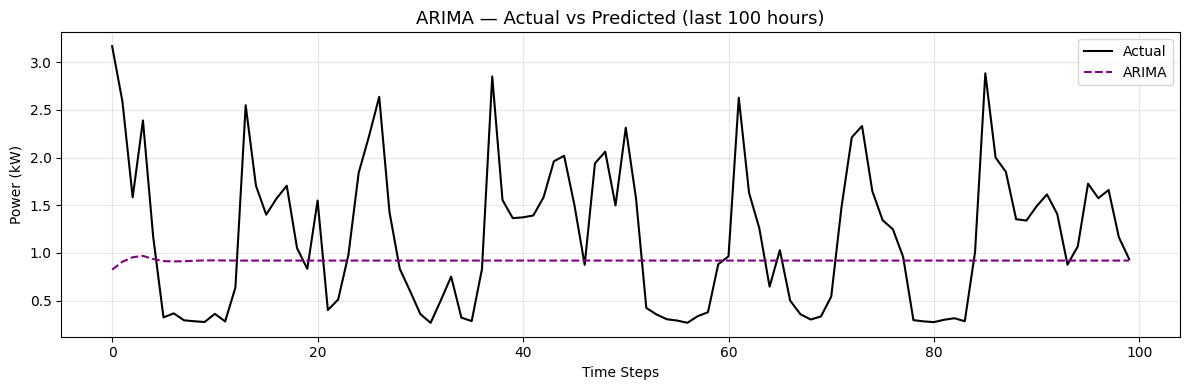

In [19]:
# ARIMA works on the series directly — use a small recent sample
arima_series = hourly['Global_active_power'].dropna()

# Use last 500 points only — ARIMA is slow on large data
arima_train = arima_series.iloc[-500:-100]
arima_test  = arima_series.iloc[-100:]

arima_model = ARIMA(arima_train, order=(5, 1, 0))
arima_fit   = arima_model.fit()
arima_pred  = arima_fit.forecast(steps=100)

arima_metrics = evaluate("ARIMA", arima_test.values, arima_pred.values)
results.append(arima_metrics)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(range(100), arima_test.values,  color='black',  linewidth=1.5, label='Actual')
plt.plot(range(100), arima_pred.values,  color='purple', linewidth=1.5,
         linestyle='--', label='ARIMA')
plt.title('ARIMA — Actual vs Predicted (last 100 hours)', fontsize=13)
plt.xlabel('Time Steps')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_arima.png', dpi=150)
plt.show()

##**Prepare Data for LSTM and GRU**

In [20]:
# Scale the target
scaler = MinMaxScaler()
gap_values = hourly['Global_active_power'].dropna().values.reshape(-1, 1)
scaled     = scaler.fit_transform(gap_values)

# Create sequences
def create_sequences(data, seq_len=24):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(data)):
        X_seq.append(data[i-seq_len:i, 0])
        y_seq.append(data[i, 0])
    return np.array(X_seq), np.array(y_seq)

SEQ_LEN = 24
X_seq, y_seq = create_sequences(scaled, SEQ_LEN)

# Chronological split
split = int(len(X_seq) * 0.8)
X_tr, X_te = X_seq[:split], X_seq[split:]
y_tr, y_te = y_seq[:split], y_seq[split:]

# Reshape for Keras [samples, timesteps, features]
X_tr = X_tr.reshape(-1, SEQ_LEN, 1)
X_te = X_te.reshape(-1, SEQ_LEN, 1)

print("LSTM/GRU input shape:", X_tr.shape)

LSTM/GRU input shape: (27652, 24, 1)


##**Model 5: LSTM**

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0150 - val_loss: 0.0118
Epoch 2/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0105 - val_loss: 0.0105
Epoch 3/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0097 - val_loss: 0.0095
Epoch 4/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0094 - val_loss: 0.0098
Epoch 5/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0092 - val_loss: 0.0094
Epoch 6/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0091 - val_loss: 0.0093
Epoch 7/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0090 - val_loss: 0.0092
Epoch 8/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0090 - val_loss: 0.0091
Epoch 9/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0089 - val_loss: 0.0091
Epoch 10/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0089 - val_loss: 0.0090
Epoch 11/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0088 - val_loss: 0.0092
Epoch 12/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/

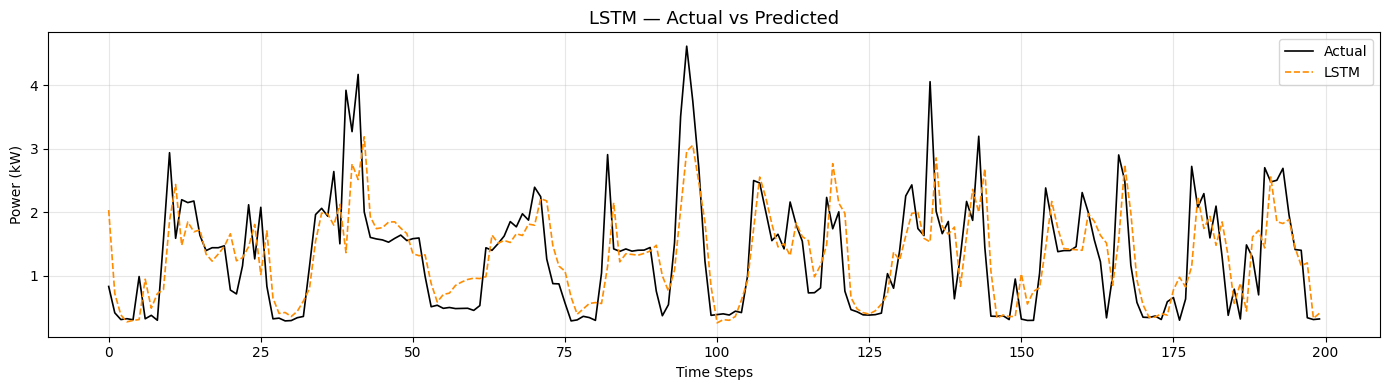

In [21]:
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

es = EarlyStopping(patience=3, restore_best_weights=True)

lstm_history = lstm_model.fit(
    X_tr, y_tr,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

# Predict and inverse transform
lstm_pred_scaled = lstm_model.predict(X_te)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()
lstm_actual = scaler.inverse_transform(y_te.reshape(-1, 1)).flatten()

lstm_metrics = evaluate("LSTM", lstm_actual, lstm_pred)
results.append(lstm_metrics)

# Plot
plt.figure(figsize=(14, 4))
plt.plot(range(200), lstm_actual[:200], color='black',  linewidth=1.2, label='Actual')
plt.plot(range(200), lstm_pred[:200],   color='darkorange', linewidth=1.2,
         linestyle='--', label='LSTM')
plt.title('LSTM — Actual vs Predicted', fontsize=13)
plt.xlabel('Time Steps')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_lstm.png', dpi=150)
plt.show()

##**Model 6: GRU**

Epoch 1/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0118 - val_loss: 0.0107
Epoch 2/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0102 - val_loss: 0.0108
Epoch 3/20
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0098 - val_loss: 0.0101
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

  GRU
  MAE    : 0.3985
  RMSE   : 0.5400
  MAPE   : 60.45%
  R2     : 0.4538


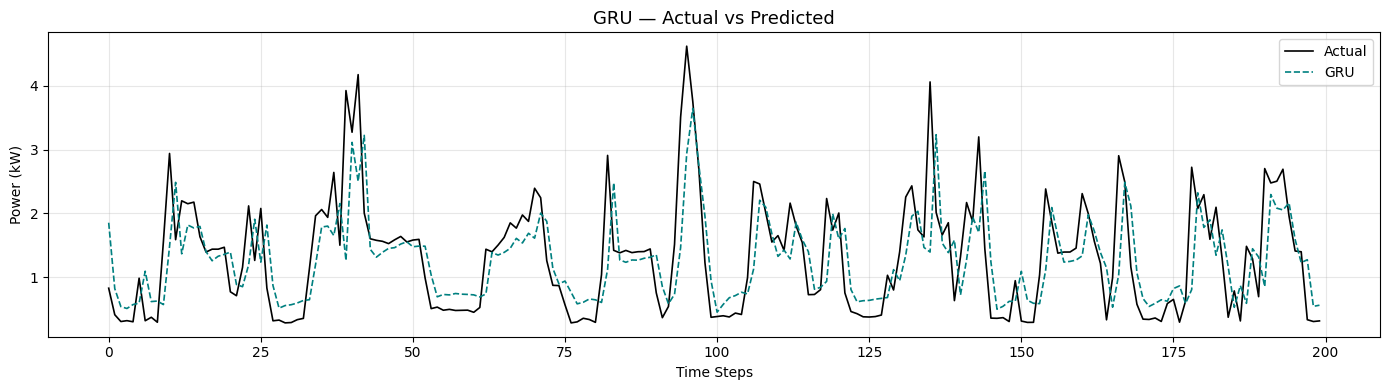

In [22]:
gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse')

gru_history = gru_model.fit(
    X_tr, y_tr,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

# Predict and inverse transform
gru_pred_scaled = gru_model.predict(X_te)
gru_pred   = scaler.inverse_transform(gru_pred_scaled).flatten()
gru_actual = scaler.inverse_transform(y_te.reshape(-1, 1)).flatten()

gru_metrics = evaluate("GRU", gru_actual, gru_pred)
results.append(gru_metrics)

# Plot
plt.figure(figsize=(14, 4))
plt.plot(range(200), gru_actual[:200], color='black', linewidth=1.2, label='Actual')
plt.plot(range(200), gru_pred[:200],   color='teal',  linewidth=1.2,
         linestyle='--', label='GRU')
plt.title('GRU — Actual vs Predicted', fontsize=13)
plt.xlabel('Time Steps')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_gru.png', dpi=150)
plt.show()

##**Model Comparison Table**

In [23]:
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('R2', ascending=False).reset_index(drop=True)

print("\n" + "="*60)
print("         FINAL MODEL COMPARISON TABLE")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)

best = comparison_df.iloc[0]
print(f"\n BEST MODEL: {best['Model']}")
print(f"  R2   : {best['R2']}")
print(f"  MAE  : {best['MAE']}")
print(f"  RMSE : {best['RMSE']}")
print(f"  MAPE : {best['MAPE']}%")

# Save to CSV
comparison_df.to_csv('model_comparison.csv', index=False)
print("\nComparison table saved to model_comparison.csv")


         FINAL MODEL COMPARISON TABLE
            Model    MAE   RMSE  MAPE      R2
          XGBoost 0.3198 0.4573 42.09  0.6084
    Random Forest 0.3282 0.4657 44.57  0.5938
             LSTM 0.3517 0.5054 47.80  0.5217
Linear Regression 0.3634 0.5173 48.46  0.4989
              GRU 0.3985 0.5400 60.45  0.4538
            ARIMA 0.6488 0.7931 83.06 -0.1164

 BEST MODEL: XGBoost
  R2   : 0.6084
  MAE  : 0.3198
  RMSE : 0.4573
  MAPE : 42.09%

Comparison table saved to model_comparison.csv


##**Comparison Bar Charts**

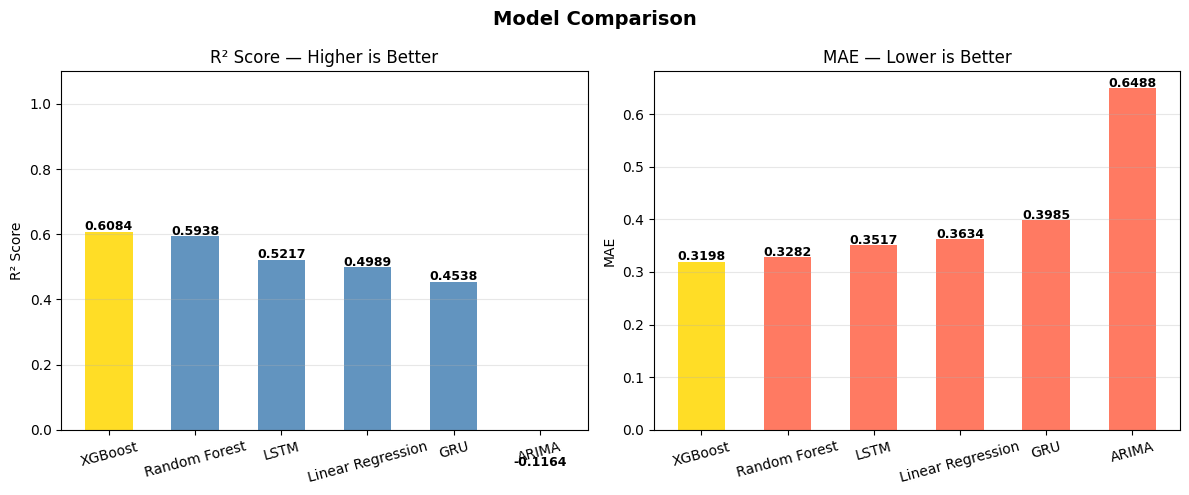

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# R2 Score
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(comparison_df))]
bars = axes[0].bar(comparison_df['Model'], comparison_df['R2'],
                   color=colors, width=0.55, alpha=0.85)
for bar, val in zip(bars, comparison_df['R2']):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.005,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('R² Score — Higher is Better', fontsize=12)
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

# MAE
colors2 = ['gold' if v == comparison_df['MAE'].min() else 'tomato'
           for v in comparison_df['MAE']]
bars2 = axes[1].bar(comparison_df['Model'], comparison_df['MAE'],
                    color=colors2, width=0.55, alpha=0.85)
for bar, val in zip(bars2, comparison_df['MAE']):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.002,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('MAE — Lower is Better', fontsize=12)
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=150)
plt.show()

##**Anomaly Detection: Z-Score**

Z-Score Anomalies detected: 440
Anomaly rate: 1.27%


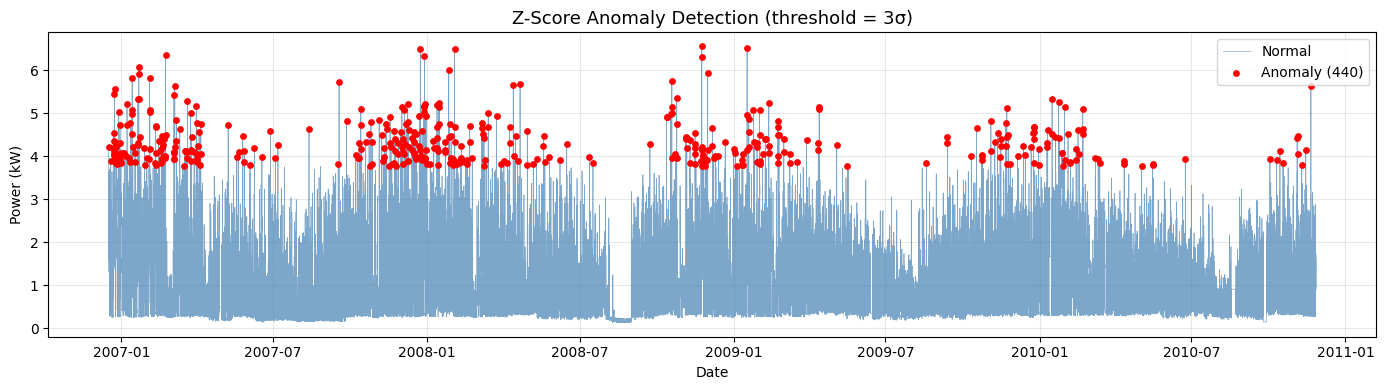


Top 5 anomaly dates:
datetime
2008-11-23 18:00:00    6.560533
2009-01-16 20:00:00    6.519633
2008-02-02 19:00:00    6.496033
2007-12-23 19:00:00    6.488000
2007-02-22 21:00:00    6.363867
Name: Global_active_power, dtype: float64


In [25]:
series = hourly['Global_active_power'].dropna()
z      = zscore(series)
z_ser  = pd.Series(z, index=series.index)
z_anom = series[abs(z_ser) > 3.0]

print(f"Z-Score Anomalies detected: {len(z_anom)}")
print(f"Anomaly rate: {len(z_anom)/len(series)*100:.2f}%")

plt.figure(figsize=(14, 4))
plt.plot(series.index, series.values,
         color='steelblue', linewidth=0.5, alpha=0.7, label='Normal')
plt.scatter(z_anom.index, z_anom.values,
            color='red', s=15, zorder=5, label=f'Anomaly ({len(z_anom)})')
plt.title('Z-Score Anomaly Detection (threshold = 3σ)', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('anomaly_zscore.png', dpi=150)
plt.show()

print("\nTop 5 anomaly dates:")
print(z_anom.abs().nlargest(5))

##**Anomaly Detection: Isolation Forest**

Isolation Forest Anomalies: 686
Anomaly rate: 1.98%


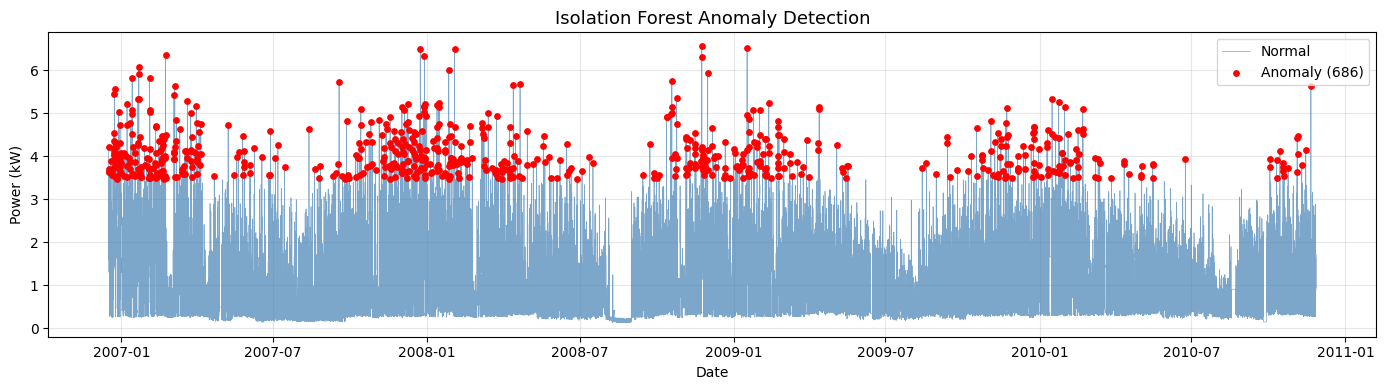

In [26]:
iso_model = IsolationForest(contamination=0.02, random_state=42)
iso_preds = iso_model.fit_predict(series.values.reshape(-1, 1))
iso_anom  = series[iso_preds == -1]

print(f"Isolation Forest Anomalies: {len(iso_anom)}")
print(f"Anomaly rate: {len(iso_anom)/len(series)*100:.2f}%")

plt.figure(figsize=(14, 4))
plt.plot(series.index, series.values,
         color='steelblue', linewidth=0.5, alpha=0.7, label='Normal')
plt.scatter(iso_anom.index, iso_anom.values,
            color='red', s=15, zorder=5, label=f'Anomaly ({len(iso_anom)})')
plt.title('Isolation Forest Anomaly Detection', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('anomaly_isoforest.png', dpi=150)
plt.show()

##**Anomaly Detection: Rolling Threshold**

Rolling Threshold Anomalies: 1771
Anomaly rate: 5.12%


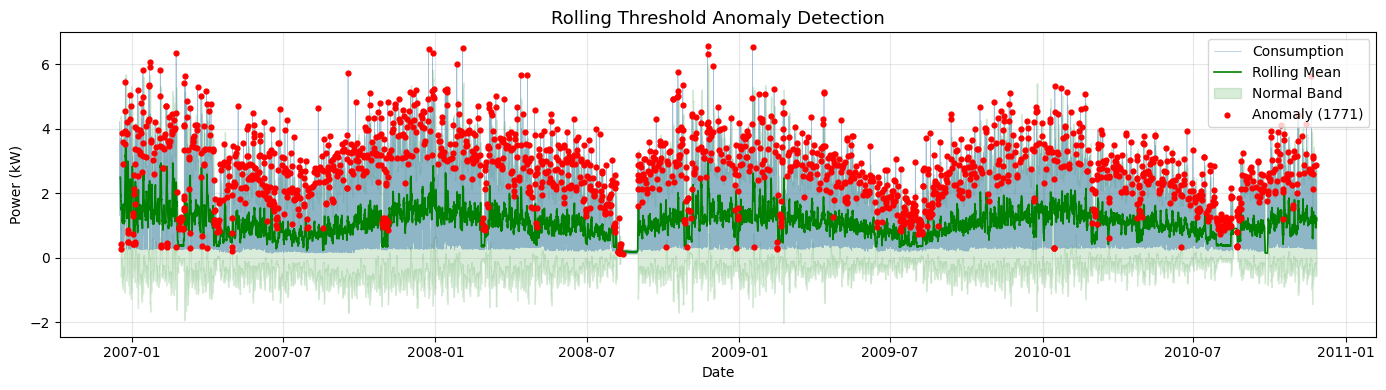

In [27]:
roll_mean = series.rolling(24).mean()
roll_std  = series.rolling(24).std()
upper     = roll_mean + 2 * roll_std
lower     = roll_mean - 2 * roll_std
roll_anom = series[(series > upper) | (series < lower)]

print(f"Rolling Threshold Anomalies: {len(roll_anom)}")
print(f"Anomaly rate: {len(roll_anom)/len(series)*100:.2f}%")

plt.figure(figsize=(14, 4))
plt.plot(series.index, series.values,
         color='steelblue', linewidth=0.5, alpha=0.5, label='Consumption')
plt.plot(roll_mean.index, roll_mean.values,
         color='green', linewidth=1.2, label='Rolling Mean')
plt.fill_between(upper.index, lower.values, upper.values,
                 alpha=0.15, color='green', label='Normal Band')
plt.scatter(roll_anom.index, roll_anom.values,
            color='red', s=12, zorder=5, label=f'Anomaly ({len(roll_anom)})')
plt.title('Rolling Threshold Anomaly Detection', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('anomaly_rolling.png', dpi=150)
plt.show()

In [29]:
import joblib

joblib.dump(lr_model,  'lr_model.pkl')
joblib.dump(rf_model,  'rf_model.pkl')
joblib.dump(xgb_model, 'xgb_model.pkl')
lstm_model.save('lstm_model.h5')
gru_model.save('gru_model.h5')

print("All models saved")

All models saved


In [30]:
from google.colab import files
import os

# List of files to download
to_download = [
    'final_electricity_dataset.csv',
    'model_comparison.csv',
    'rf_model.pkl',
    'xgb_model.pkl',
    'lr_model.pkl',
    'lstm_model.h5',
    'gru_model.h5',
]

for f in to_download:
    if os.path.exists(f):
        files.download(f)
        print(f"Downloaded: {f}")
    else:
        print(f"NOT FOUND: {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: final_electricity_dataset.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: lstm_model.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: gru_model.h5
